In [1]:
# Fix version incompatibilities (run once, then restart runtime)
!pip install -q --upgrade numpy scipy scikit-learn


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:

# ============================================================
# 1. Load Data
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('dialogs_train_annotated.tsv', sep='\t', on_bad_lines='skip')
val_df   = pd.read_csv('dialogs_val_annotated.tsv',   sep='\t', on_bad_lines='skip')
test_df  = pd.read_csv('dialogs_test_annotated.tsv',  sep='\t', on_bad_lines='skip')

# Labels: Intent column (4 classes)
intent_order = ['focus', 'generic', 'probing', 'telling']

print(f"{'Split':<8} {'Rows':<8} {'Dialogs':<10} {'Teacher turns':<15}")
print("-" * 45)
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    n_convs   = df['Conversation_No'].nunique()
    n_teacher = len(df[(df['Speaker'] == 'Teacher') & (df['Intent'].isin(intent_order))])
    print(f"{name:<8} {len(df):<8} {n_convs:<10} {n_teacher:<15}")

print(f"\nLabels ({len(intent_order)}): {intent_order}")
print(f"\nEach teacher turn = 1 independent training sample.")
print(f"Each sample's context is computed directly from prior turns in the same dialog.")


Split    Rows     Dialogs    Teacher turns  
---------------------------------------------
Train    8154     500        5173           
Val      160      11         100            
Test     152      10         99             

Labels (4): ['focus', 'generic', 'probing', 'telling']

Each teacher turn = 1 independent training sample.
Each sample's context is computed directly from prior turns in the same dialog.


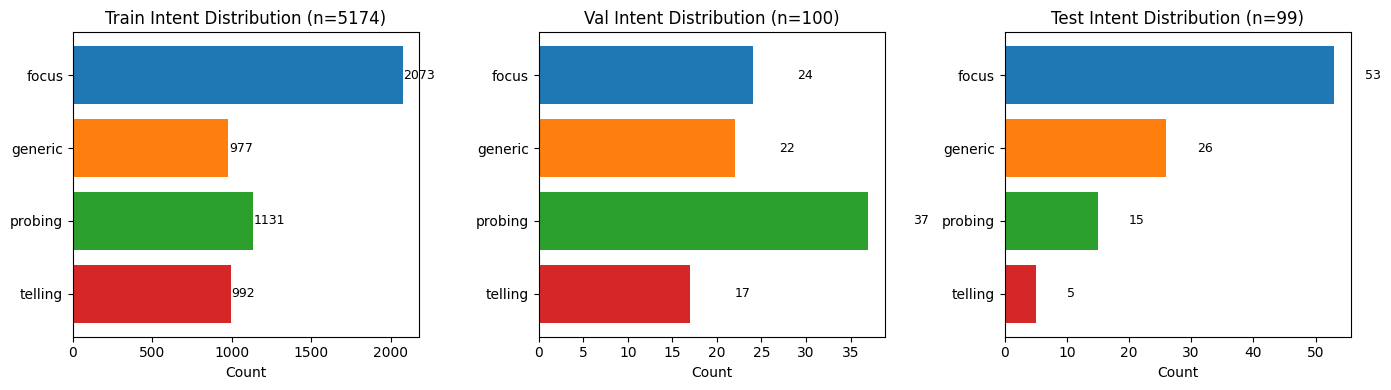

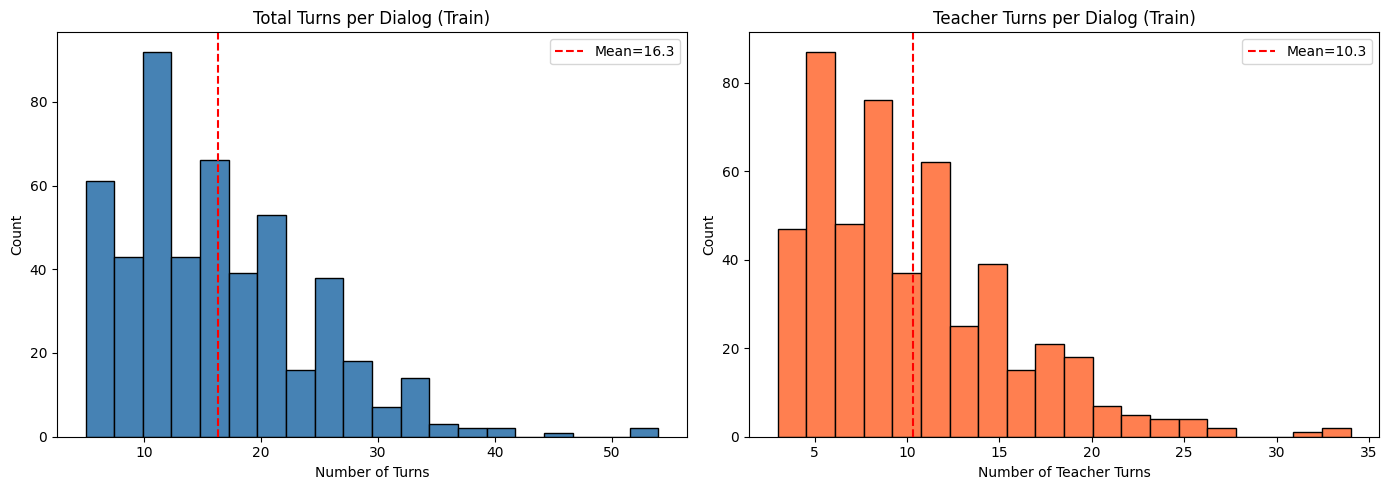

In [3]:

# ============================================================
# 2. Data Visualization
# ============================================================
train_teacher = train_df[train_df['Speaker'] == 'Teacher'].copy()
val_teacher   = val_df[val_df['Speaker'] == 'Teacher'].copy()
test_teacher  = test_df[test_df['Speaker'] == 'Teacher'].copy()
colors = sns.color_palette("tab10", len(intent_order))

# --- Intent distribution across splits ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, df_t) in zip(axes, [('Train', train_teacher), ('Val', val_teacher), ('Test', test_teacher)]):
    counts = df_t['Intent'].value_counts().reindex(intent_order, fill_value=0)
    bars = ax.barh(intent_order, counts, color=colors)
    ax.set_title(f'{name} Intent Distribution (n={len(df_t)})', fontsize=12)
    ax.set_xlabel('Count')
    for bar, c in zip(bars, counts):
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, str(int(c)), va='center', fontsize=9)
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

# --- Turns per dialog & utterance lengths ---
conv_lengths = train_df.groupby('Conversation_No').size()
teacher_turns_per_conv = train_teacher.groupby('Conversation_No').size()
train_teacher['text_len'] = train_teacher['Text'].astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(conv_lengths, bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Total Turns per Dialog (Train)')
axes[0].set_xlabel('Number of Turns'); axes[0].set_ylabel('Count')
axes[0].axvline(conv_lengths.mean(), color='red', linestyle='--', label=f'Mean={conv_lengths.mean():.1f}')
axes[0].legend()

axes[1].hist(teacher_turns_per_conv, bins=20, color='coral', edgecolor='black')
axes[1].set_title('Teacher Turns per Dialog (Train)')
axes[1].set_xlabel('Number of Teacher Turns'); axes[1].set_ylabel('Count')
axes[1].axvline(teacher_turns_per_conv.mean(), color='red', linestyle='--', label=f'Mean={teacher_turns_per_conv.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()


In [4]:

# ============================================================
# 3. Data Preparation — Independent Dialog-Turn Samples
# ============================================================
# Each teacher turn in a dialog = 1 independent training sample.
# Label = Intent column (4 classes).
# Context tags on prior teacher turns also use Intent.
#
# V1: prior context (with intents) + current teacher utterance → predict current intent
# V2: prior context (with intents) only                        → predict current intent

def build_dialog_samples(df):
    """
    Each teacher turn = 1 independent sample.
    Context for turn i is built by reading turns[:i] directly — no incremental state.
    Uses Intent as labels and context tags.
    """
    v1_samples, v2_samples = [], []

    for conv_no, conv_df in df.groupby('Conversation_No'):
        conv_df = conv_df.sort_values('Utterance_Index')
        turns = conv_df[['Speaker', 'Text', 'Intent']].values.tolist()

        for i, (speaker, text, intent) in enumerate(turns):
            if speaker == 'Teacher' and pd.notna(intent) and intent in intent_order:

                # Build context independently: read ALL prior turns for this sample
                prior_parts = []
                for prev_speaker, prev_text, prev_intent in turns[:i]:
                    if prev_speaker == 'Teacher' and pd.notna(prev_intent) and prev_intent in intent_order:
                        prior_parts.append(f"Teacher [{prev_intent}]: {str(prev_text)}")
                    elif prev_speaker == 'Student':
                        prior_parts.append(f"Student: {str(prev_text)}")

                current_utterance = f"Teacher: {str(text)}"

                # V1: prior context + current teacher utterance
                v1_text = " [SEP] ".join(prior_parts + [current_utterance]) if prior_parts else current_utterance
                # V2: prior context only
                v2_text = " [SEP] ".join(prior_parts) if prior_parts else "[NO CONTEXT]"

                v1_samples.append({'text': v1_text, 'label': intent, 'conv': conv_no, 'turn': i})
                v2_samples.append({'text': v2_text, 'label': intent, 'conv': conv_no, 'turn': i})

    return pd.DataFrame(v1_samples), pd.DataFrame(v2_samples)


train_v1, train_v2 = build_dialog_samples(train_df)
val_v1,   val_v2   = build_dialog_samples(val_df)
test_v1,  test_v2  = build_dialog_samples(test_df)

assert len(train_v1) == len(train_v2)
assert len(val_v1)   == len(val_v2)
assert len(test_v1)  == len(test_v2)

print(f"{'Split':<8} {'Dialogs':<10} {'Samples (per version)':<22}")
print("-" * 42)
for name, v1, df in [('Train', train_v1, train_df), ('Val', val_v1, val_df), ('Test', test_v1, test_df)]:
    print(f"{name:<8} {df['Conversation_No'].nunique():<10} {len(v1):<22}")

print(f"\nTrain label distribution:\n{train_v1['label'].value_counts()}")


Split    Dialogs    Samples (per version) 
------------------------------------------
Train    500        5173                  
Val      11         100                   
Test     10         99                    

Train label distribution:
label
focus      2073
probing    1131
telling     992
generic     977
Name: count, dtype: int64


In [5]:
# ============================================================
# 4. Inspect Samples from One Dialog
# ============================================================
# Each sample is independently constructed — prior turns are read
# directly for that sample, not inherited from a previous sample.

sample_conv = train_v1['conv'].unique()[0]
conv_v1 = train_v1[train_v1['conv'] == sample_conv]
conv_v2 = train_v2[train_v2['conv'] == sample_conv]

print(f"Dialog {sample_conv}: {len(conv_v1)} teacher turns → {len(conv_v1)} independent samples\n")

for i, (_, row_v1) in enumerate(conv_v1.iterrows()):
    row_v2 = conv_v2.iloc[i]
    print(f"{'=' * 70}")
    print(f"SAMPLE {i+1}/{len(conv_v1)} (dialog position {row_v1['turn']}) — Label: {row_v1['label']}")
    print(f"{'=' * 70}")

    print(f"\n  V1 INPUT ({len(row_v1['text'].split(' [SEP] '))} parts):")
    for part in row_v1['text'].split(' [SEP] '):
        print(f"    {part[:120]}{'...' if len(part) > 120 else ''}")

    print(f"\n  V2 INPUT ({len(row_v2['text'].split(' [SEP] '))} parts):")
    for part in row_v2['text'].split(' [SEP] '):
        print(f"    {part[:120]}{'...' if len(part) > 120 else ''}")
    print()

    if i >= 3:
        remaining = len(conv_v1) - 4
        if remaining > 0:
            print(f"  ... and {remaining} more independent samples from this dialog")
        break

Dialog 0: 6 teacher turns → 6 independent samples

SAMPLE 1/6 (dialog position 0) — Label: generic

  V1 INPUT (1 parts):
    Teacher: Hi Jian, Can you please take me through your solution?

  V2 INPUT (1 parts):
    [NO CONTEXT]

SAMPLE 2/6 (dialog position 2) — Label: generic

  V1 INPUT (3 parts):
    Teacher [generic]: Hi Jian, Can you please take me through your solution?
    Student: Sure. I calculated that for the 5 kilograms cargo, Cherry earns 4 x 2.50 = $10 per day for delivering four 5 ki...
    Teacher: This is great.

  V2 INPUT (2 parts):
    Teacher [generic]: Hi Jian, Can you please take me through your solution?
    Student: Sure. I calculated that for the 5 kilograms cargo, Cherry earns 4 x 2.50 = $10 per day for delivering four 5 ki...

SAMPLE 3/6 (dialog position 3) — Label: generic

  V1 INPUT (4 parts):
    Teacher [generic]: Hi Jian, Can you please take me through your solution?
    Student: Sure. I calculated that for the 5 kilograms cargo, Cherry earns 4 x 2.50

In [6]:
# ============================================================
# 5. Tokenization & Datasets
# ============================================================
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

label2id = {label: i for i, label in enumerate(intent_order)}
id2label = {i: label for label, i in label2id.items()}
num_labels = len(intent_order)
print(f"Labels: {label2id}")

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.encodings = tokenizer(
            texts, truncation=True, padding='max_length',
            max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor([label2id[l] for l in labels], dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels[idx]
        }

MAX_LEN = 512
BATCH_SIZE = 16

train_ds_v1 = IntentDataset(train_v1['text'].tolist(), train_v1['label'].tolist(), tokenizer, MAX_LEN)
val_ds_v1   = IntentDataset(val_v1['text'].tolist(),   val_v1['label'].tolist(),   tokenizer, MAX_LEN)
test_ds_v1  = IntentDataset(test_v1['text'].tolist(),  test_v1['label'].tolist(),  tokenizer, MAX_LEN)

train_ds_v2 = IntentDataset(train_v2['text'].tolist(), train_v2['label'].tolist(), tokenizer, MAX_LEN)
val_ds_v2   = IntentDataset(val_v2['text'].tolist(),   val_v2['label'].tolist(),   tokenizer, MAX_LEN)
test_ds_v2  = IntentDataset(test_v2['text'].tolist(),  test_v2['label'].tolist(),  tokenizer, MAX_LEN)

train_loader_v1 = DataLoader(train_ds_v1, batch_size=BATCH_SIZE, shuffle=True)
val_loader_v1   = DataLoader(val_ds_v1,   batch_size=BATCH_SIZE)
test_loader_v1  = DataLoader(test_ds_v1,  batch_size=BATCH_SIZE)

train_loader_v2 = DataLoader(train_ds_v2, batch_size=BATCH_SIZE, shuffle=True)
val_loader_v2   = DataLoader(val_ds_v2,   batch_size=BATCH_SIZE)
test_loader_v2  = DataLoader(test_ds_v2,  batch_size=BATCH_SIZE)

print(f"\nV1 sizes — Train: {len(train_ds_v1)}, Val: {len(val_ds_v1)}, Test: {len(test_ds_v1)}")
print(f"V2 sizes — Train: {len(train_ds_v2)}, Val: {len(val_ds_v2)}, Test: {len(test_ds_v2)}")

Using device: cuda
Labels: {'focus': 0, 'generic': 1, 'probing': 2, 'telling': 3}


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


V1 sizes — Train: 5173, Val: 100, Test: 99
V2 sizes — Train: 5173, Val: 100, Test: 99


In [7]:
# ============================================================
# 6. Training & Evaluation Functions
# ============================================================
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, acc, f1, all_preds, all_labels


def train_model(train_loader, val_loader, save_name, epochs=15, lr=2e-5, class_weights=None):
    model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased',
        num_labels=num_labels, id2label=id2label, label2id=label2id
    ).to(device)

    optimizer    = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps  = len(train_loader) * epochs
    scheduler    = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    # Use weighted loss when class_weights are provided (mirrors Qwen WeightedLossTrainer)
    loss_fct = torch.nn.CrossEntropyLoss(
        weight=class_weights.to(device) if class_weights is not None else None
    )

    history    = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_val_f1 = 0

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fct(outputs.logits, labels)
            total_train_loss += loss.item()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        avg_train_loss = total_train_loss / len(train_loader)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), save_name)

        print(f"  Epoch {epoch+1:>2}/{epochs} | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    print(f"  Best Val F1: {best_val_f1:.4f}\n")
    return model, history

print("Training functions defined.")


Training functions defined.


In [8]:
# ============================================================
# 7. Train V1 Model
# ============================================================
print("=" * 60)
print("Training V1: history + current teacher utterance")
print("=" * 60)
model_v1, history_v1 = train_model(train_loader_v1, val_loader_v1, 'best_v1.pt', epochs=15)


Training V1: history + current teacher utterance


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch  1/15 | Train Loss: 1.2255 | Val Loss: 1.1535 | Val Acc: 0.5200 | Val F1: 0.5211
  Epoch  2/15 | Train Loss: 0.9054 | Val Loss: 0.8612 | Val Acc: 0.6300 | Val F1: 0.6388
  Epoch  3/15 | Train Loss: 0.7728 | Val Loss: 0.8998 | Val Acc: 0.6100 | Val F1: 0.6182
  Epoch  4/15 | Train Loss: 0.6643 | Val Loss: 0.7946 | Val Acc: 0.6400 | Val F1: 0.6473
  Epoch  5/15 | Train Loss: 0.5849 | Val Loss: 0.7057 | Val Acc: 0.7000 | Val F1: 0.7016
  Epoch  6/15 | Train Loss: 0.4858 | Val Loss: 0.7984 | Val Acc: 0.6900 | Val F1: 0.6896
  Epoch  7/15 | Train Loss: 0.4222 | Val Loss: 0.8321 | Val Acc: 0.6900 | Val F1: 0.6956
  Epoch  8/15 | Train Loss: 0.3442 | Val Loss: 0.8875 | Val Acc: 0.7300 | Val F1: 0.7294
  Epoch  9/15 | Train Loss: 0.2913 | Val Loss: 0.9993 | Val Acc: 0.7000 | Val F1: 0.7002
  Epoch 10/15 | Train Loss: 0.2500 | Val Loss: 0.9949 | Val Acc: 0.7100 | Val F1: 0.7119
  Epoch 11/15 | Train Loss: 0.2268 | Val Loss: 1.1852 | Val Acc: 0.7000 | Val F1: 0.7041
  Epoch 12/15 | Train

In [ ]:
# ============================================================
# 8. Train V2 Model
# ============================================================
print("=" * 60)
print("Training V2: history only (no current utterance)")
print("=" * 60)
model_v2, history_v2 = train_model(train_loader_v2, val_loader_v2, 'best_v2.pt', epochs=15)


Training V2: history only (no current utterance)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch  1/15 | Train Loss: 1.2137 | Val Loss: 1.0649 | Val Acc: 0.6300 | Val F1: 0.6345
  Epoch  2/15 | Train Loss: 0.9467 | Val Loss: 0.9895 | Val Acc: 0.6700 | Val F1: 0.6677
  Epoch  3/15 | Train Loss: 0.8700 | Val Loss: 0.9065 | Val Acc: 0.6200 | Val F1: 0.6237
  Epoch  4/15 | Train Loss: 0.7970 | Val Loss: 0.8629 | Val Acc: 0.6400 | Val F1: 0.6416
  Epoch  5/15 | Train Loss: 0.7220 | Val Loss: 0.7557 | Val Acc: 0.7000 | Val F1: 0.7049
  Epoch  6/15 | Train Loss: 0.6439 | Val Loss: 0.7987 | Val Acc: 0.6400 | Val F1: 0.6431
  Epoch  7/15 | Train Loss: 0.5678 | Val Loss: 0.8309 | Val Acc: 0.6700 | Val F1: 0.6740
  Epoch  8/15 | Train Loss: 0.4958 | Val Loss: 0.8100 | Val Acc: 0.7100 | Val F1: 0.7134
  Epoch  9/15 | Train Loss: 0.4350 | Val Loss: 0.7662 | Val Acc: 0.7200 | Val F1: 0.7244
  Epoch 10/15 | Train Loss: 0.3860 | Val Loss: 0.7751 | Val Acc: 0.7300 | Val F1: 0.7330
  Epoch 11/15 | Train Loss: 0.3590 | Val Loss: 0.8723 | Val Acc: 0.7300 | Val F1: 0.7331
  Epoch 12/15 | Train

In [ ]:
# ============================================================
# 9. Training Curves
# ============================================================
epochs_range = range(1, 16)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training Curves — V1 (top) vs V2 (bottom)', fontsize=15)

for row, (history, label) in enumerate([(history_v1, 'V1'), (history_v2, 'V2')]):
    # Loss
    axes[row, 0].plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', color='steelblue')
    axes[row, 0].plot(epochs_range, history['val_loss'],   's--', label='Val Loss',   color='coral')
    axes[row, 0].set_title(f'{label} — Loss')
    axes[row, 0].set_xlabel('Epoch'); axes[row, 0].set_ylabel('Loss')
    axes[row, 0].legend(); axes[row, 0].grid(alpha=0.3)

    # Accuracy
    axes[row, 1].plot(epochs_range, history['val_acc'], 'o-', color='seagreen')
    axes[row, 1].set_title(f'{label} — Validation Accuracy')
    axes[row, 1].set_xlabel('Epoch'); axes[row, 1].set_ylabel('Accuracy')
    axes[row, 1].set_ylim(0, 1); axes[row, 1].grid(alpha=0.3)
    best_acc_ep = history['val_acc'].index(max(history['val_acc'])) + 1
    axes[row, 1].axvline(best_acc_ep, color='red', linestyle='--', alpha=0.5, label=f'Best @ E{best_acc_ep}')
    axes[row, 1].legend()

    # F1
    axes[row, 2].plot(epochs_range, history['val_f1'], 'o-', color='mediumpurple')
    axes[row, 2].set_title(f'{label} — Validation Weighted F1')
    axes[row, 2].set_xlabel('Epoch'); axes[row, 2].set_ylabel('F1')
    axes[row, 2].set_ylim(0, 1); axes[row, 2].grid(alpha=0.3)
    best_f1_ep = history['val_f1'].index(max(history['val_f1'])) + 1
    axes[row, 2].axvline(best_f1_ep, color='red', linestyle='--', alpha=0.5, label=f'Best @ E{best_f1_ep}')
    axes[row, 2].legend()

plt.tight_layout()
plt.show()

print(f"V1 — Best Val F1: {max(history_v1['val_f1']):.4f} (Epoch {history_v1['val_f1'].index(max(history_v1['val_f1']))+1})")
print(f"V2 — Best Val F1: {max(history_v2['val_f1']):.4f} (Epoch {history_v2['val_f1'].index(max(history_v2['val_f1']))+1})")

In [ ]:
# ============================================================
# 10. Test Evaluation — V1 (load best checkpoint)
# ============================================================
model_v1.load_state_dict(torch.load('best_v1.pt', map_location=device))
_, test_acc_v1, test_f1_v1, preds_v1, labels_v1 = evaluate(model_v1, test_loader_v1)

print("=" * 60)
print(f"V1 Test Results  |  Acc: {test_acc_v1:.4f}  |  Weighted F1: {test_f1_v1:.4f}")
print("=" * 60)
print(classification_report(
    labels_v1, preds_v1,
    labels=list(range(num_labels)),
    target_names=intent_order,
    digits=4,
    zero_division=0
))

In [ ]:
# ============================================================
# 11. Test Evaluation — V2 (load best checkpoint)
# ============================================================
model_v2.load_state_dict(torch.load('best_v2.pt', map_location=device))
_, test_acc_v2, test_f1_v2, preds_v2, labels_v2 = evaluate(model_v2, test_loader_v2)

print("=" * 60)
print(f"V2 Test Results  |  Acc: {test_acc_v2:.4f}  |  Weighted F1: {test_f1_v2:.4f}")
print("=" * 60)
print(classification_report(
    labels_v2, preds_v2,
    labels=list(range(num_labels)),
    target_names=intent_order,
    digits=4,
    zero_division=0
))

In [ ]:
# ============================================================
# 12. Confusion Matrices — V1 vs V2
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrices on Test Set', fontsize=14)

for ax, preds, true_labels, title in [
    (axes[0], preds_v1, labels_v1, 'V1: history + current utterance'),
    (axes[1], preds_v2, labels_v2, 'V2: history only'),
]:
    cm = confusion_matrix(true_labels, preds, labels=list(range(num_labels)))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=intent_order, yticklabels=intent_order,
        ax=ax, linewidths=0.5
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 13. Summary Comparison Table
# ============================================================
print("=" * 75)
print(f"{'SUMMARY':^75}")
print("=" * 75)
print(f"\n{'Metric':<40} {'V1':>15} {'V2':>15}")
print("-" * 70)

# Training summary
print(f"{'Best Val F1 (during training)':<40} {max(history_v1['val_f1']):>15.4f} {max(history_v2['val_f1']):>15.4f}")
best_ep_v1 = history_v1['val_f1'].index(max(history_v1['val_f1'])) + 1
best_ep_v2 = history_v2['val_f1'].index(max(history_v2['val_f1'])) + 1
print(f"{'Best Epoch':<40} {best_ep_v1:>15} {best_ep_v2:>15}")
print(f"{'Final Train Loss':<40} {history_v1['train_loss'][-1]:>15.4f} {history_v2['train_loss'][-1]:>15.4f}")

print("-" * 70)

# Test results
print(f"{'Test Accuracy':<40} {test_acc_v1:>15.4f} {test_acc_v2:>15.4f}")
print(f"{'Test Weighted F1':<40} {test_f1_v1:>15.4f} {test_f1_v2:>15.4f}")

print("-" * 70)

# Per-class F1 on test
from sklearn.metrics import f1_score as sk_f1
for intent in intent_order:
    idx = label2id[intent]
    f1_v1 = sk_f1([1 if l == idx else 0 for l in labels_v1],
                   [1 if p == idx else 0 for p in preds_v1], zero_division=0)
    f1_v2 = sk_f1([1 if l == idx else 0 for l in labels_v2],
                   [1 if p == idx else 0 for p in preds_v2], zero_division=0)
    print(f"  Test F1 [{intent}]  {f1_v1:>15.4f} {f1_v2:>15.4f}")

print("=" * 75)
print("\nV1 = sees current utterance + history → classifies current intent")
print("V2 = history only → predicts next teacher intent without seeing it")
print(f"\nTrain: {len(train_v1)} samples | Val: {len(val_v1)} samples | Test: {len(test_v1)} samples")


In [ ]:
# ============================================================
# 14. Save Models, Predictions & Training Histories
# ============================================================
import os, json

os.makedirs('saved_v1', exist_ok=True)
os.makedirs('saved_v2', exist_ok=True)

# --- Save models in HuggingFace format ---
model_v1.load_state_dict(torch.load('best_v1.pt', map_location=device))
model_v1.save_pretrained('saved_v1/model')
tokenizer.save_pretrained('saved_v1/tokenizer')

model_v2.load_state_dict(torch.load('best_v2.pt', map_location=device))
model_v2.save_pretrained('saved_v2/model')
tokenizer.save_pretrained('saved_v2/tokenizer')

print("Models saved to saved_v1/ and saved_v2/")

# --- Save predictions as CSV ---
def make_pred_df(v_df, preds, labels, version):
    df_out = v_df[['conv', 'turn', 'label']].copy().reset_index(drop=True)
    df_out['true_label']  = [id2label[l] for l in labels]
    df_out['pred_label']  = [id2label[p] for p in preds]
    df_out['correct']     = df_out['true_label'] == df_out['pred_label']
    df_out['version']     = version
    return df_out

pred_v1_df = make_pred_df(test_v1, preds_v1, labels_v1, 'V1')
pred_v2_df = make_pred_df(test_v2, preds_v2, labels_v2, 'V2')

pred_v1_df.to_csv('predictions_v1.csv', index=False)
pred_v2_df.to_csv('predictions_v2.csv', index=False)
print("Predictions saved to predictions_v1.csv and predictions_v2.csv")

# --- Save training histories as JSON ---
with open('history_v1.json', 'w') as f:
    json.dump(history_v1, f, indent=2)
with open('history_v2.json', 'w') as f:
    json.dump(history_v2, f, indent=2)
print("Training histories saved to history_v1.json and history_v2.json")

print("\nAll outputs saved successfully.")

In [ ]:
# ============================================================
# Error Analysis
# ============================================================
# Attach original text to predictions for qualitative inspection

test_v1_reset = test_v1.reset_index(drop=True)
test_v2_reset = test_v2.reset_index(drop=True)

pred_v1_df['text'] = test_v1_reset['text']
pred_v2_df['text'] = test_v2_reset['text']

errors_v1 = pred_v1_df[~pred_v1_df['correct']].copy()
errors_v2 = pred_v2_df[~pred_v2_df['correct']].copy()

print('=' * 70)
print(f'ERROR SUMMARY')
print('=' * 70)
print(f"  V1 errors: {len(errors_v1)} / {len(pred_v1_df)}  ({len(errors_v1)/len(pred_v1_df)*100:.1f}%)")
print(f"  V2 errors: {len(errors_v2)} / {len(pred_v2_df)}  ({len(errors_v2)/len(pred_v2_df)*100:.1f}%)")

# ---- Most common misclassification pairs ----
print('\n--- Most Common Misclassification Pairs ---')
for version, errors in [('V1', errors_v1), ('V2', errors_v2)]:
    print(f'\n  {version}:')
    pairs = errors.groupby(['true_label', 'pred_label']).size().sort_values(ascending=False)
    for (true, pred), count in pairs.items():
        print(f"    True: {true:<35}  Predicted: {pred:<35}  Count: {count}")

# ---- Error rate per true class ----
print('\n--- Error Rate per True Class ---')
print(f"\n  {'Class':<35} {'V1 Errors':>10} {'V1 Total':>10} {'V1 Err%':>10}  |  {'V2 Errors':>10} {'V2 Total':>10} {'V2 Err%':>10}")
print('  ' + '-' * 100)
for intent in intent_order:
    v1_total  = (pred_v1_df['true_label'] == intent).sum()
    v1_errors = len(errors_v1[errors_v1['true_label'] == intent])
    v2_total  = (pred_v2_df['true_label'] == intent).sum()
    v2_errors = len(errors_v2[errors_v2['true_label'] == intent])
    print(f"  {intent:<35} {v1_errors:>10} {v1_total:>10} {v1_errors/v1_total*100 if v1_total else 0:>9.1f}%  |  "
          f"{v2_errors:>10} {v2_total:>10} {v2_errors/v2_total*100 if v2_total else 0:>9.1f}%")

# ---- Qualitative examples ----
N_EXAMPLES = 3  # examples per confusion pair

print('\n' + '=' * 70)
print('QUALITATIVE ERROR EXAMPLES')
print('=' * 70)

for version, errors in [('V1 (context + current utterance)', errors_v1),
                         ('V2 (context only)',               errors_v2)]:
    print(f'\n{"─" * 70}')
    print(f'  {version}')
    print(f'{"─" * 70}')
    pairs = errors.groupby(['true_label', 'pred_label']).size().sort_values(ascending=False)
    for (true, pred), count in pairs.items():
        subset = errors[(errors['true_label'] == true) & (errors['pred_label'] == pred)]
        print(f'\n  True: [{true}]  →  Predicted: [{pred}]  ({count} case{"s" if count > 1 else ""})')
        for i, (_, row) in enumerate(subset.head(N_EXAMPLES).iterrows()):
            text_preview = row['text'][:350].replace('\n', ' ')
            if len(row['text']) > 350:
                text_preview += '...'
            print(f'\n    Example {i+1}:')
            print(f"    Input : {text_preview}")
            print(f"    True  : {row['true_label']}")
            print(f"    Pred  : {row['pred_label']}")

print('\n' + '=' * 70)
print('END OF ERROR ANALYSIS')
print('=' * 70)